---
title: Agent-based models and Monte Carlo simulations
short_title: "Day 3: Monte Carlo methods"
---

# Agent-based models and Monte Carlo simulations

## Random number generators in numpy

Monte Carlo simulation is good way to investigate stochastic/probabilistic processes. In order to run Monte Carlo simulations we need to generate random samples from probability distributions, and the required utilities can be found in the `numpy.random` module

Note that the `numpy.random` module provides both a legacy interface (functions of the forms `np.random.<name>()`) and a Generator interface (first use  `np.random.default_rng()` to create a random generator instance, and then use it to produce random samples)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Generator interface

In [2]:
# create a random generator instance
rng = np.random.default_rng()

In [3]:
# generate 10000 pairs of random numbers between 0 and 1
N_pairs = 10000
rng_pairs = rng.random(size=(N_pairs, 2))

In [4]:
# find the number of pairs that fall within the unit circle, and hence estimate pi
within_sum = np.sum((rng_pairs[:, 0]**2 + rng_pairs[:, 1]**2) < 1)
4 * within_sum / N_pairs # estimate of pi

np.float64(3.1252)

### Legacy interface

In [5]:
# generate 10000 pairs of random numbers between 0 and 1 using the legacy interface
N_pairs = 10000
rng_pairs = np.random.random(size=(N_pairs, 2))

In [6]:
# find the number of pairs that fall within the unit circle, and hence estimate pi
within_sum = np.sum((rng_pairs[:, 0]**2 + rng_pairs[:, 1]**2) < 1)
4 * within_sum / N_pairs # estimate of pi

np.float64(3.1448)

The `numpy.random` modules provide a variety of functions to generate samples from different probability distributions. For more information, read the [documentation of the random generator](https://numpy.org/doc/2.4/reference/random/generator.html) (for the generator interface), or the [documentation of the legacy generator](https://numpy.org/doc/2.4/reference/random/legacy.html) (for the legacy interface).

## Example: Monte Carlo simulation of trait dynamics

**Model overview**

1. Phenotype (conceptualized as size) identified with genotype: $Z_i = G_i$
2. Survival: $p_i = \exp\{-(Z_i - \theta)^2 / (2 \, {\sigma_S}^2)\}$; draw **Bernoulli** survival
3. Reproduction: survivors each produce offspring $\sim \text{Poisson}(\lambda_0)$ (size-independent); the survivor itself dies after reproducing.
4. Inheritance: offspring genotype $G_{\text{child}} = G_{\text{parent}} + M_i$ with $M_i \sim \mathcal{N}(0, \sigma_M)$

We will simulate **N generations**

### Setup

In [7]:
rng = np.random.default_rng()

In [8]:
N = 20 # number of generations/iterations
P0 = 10 # initial population size

In [9]:
theta = 100 # optimal size
sigma_S = 10.0 # selection sensitivity
lambda_0 = 1.2 # mean number of offsprings
sigma_M = 2.0 # mutation SD

In [10]:
# initialize the first generation

G0_mean = 90.0
G0_sd = 20.0

G0 = rng.normal(G0_mean, G0_sd, size=P0)  # breeding values (genotypes)

### Try one step of the iteration

In [11]:
p_survive = np.exp( -(G0 - theta)**2 / (2 * sigma_S**2) )

In [12]:
p_draw = rng.random(P0)

In [13]:
G1_parents = G0[p_draw < p_survive]

In [14]:
G1_parents

array([114.82760068,  99.18340329, 104.87811145, 106.88909395])

In [15]:
G1_counts = rng.poisson(lambda_0, size=len(G1_parents))
G1_total = G1_counts.sum()

In [16]:
G1_counts

array([2, 1, 1, 4])

In [17]:
G1_inh = np.zeros(G1_total)
idx_next = 0
for idx, count in enumerate(G1_counts):
    G1_inh[idx_next:(idx_next+count)] = G1_parents[idx]
    idx_next += count

In [18]:
G1_inh

array([114.82760068, 114.82760068,  99.18340329, 104.87811145,
       106.88909395, 106.88909395, 106.88909395, 106.88909395])

In [19]:
G1_mut = rng.normal(0, sigma_M, size=G1_total)

In [20]:
G1_mut

array([ 2.46533064,  3.70260148,  2.5473171 , -0.6657157 ,  0.12605557,
        2.53040533, -0.41130063,  2.28949979])

In [21]:
G1 = G1_inh + G1_mut

In [22]:
G1

array([117.29293132, 118.53020216, 101.73072039, 104.21239575,
       107.01514952, 109.41949929, 106.47779332, 109.17859375])

### Set up iteration

In [23]:
rng = np.random.default_rng()

N = 20 # number of generations/iterations
P0 = 100 # initial population size

theta = 100 # optimal size
sigma_S = 10.0 # selection sensitivity
lambda_0 = 1.2 # mean number of offsprings
sigma_M = 2.0 # mutation SD

G0_mean = 90.0
G0_sd = 20.0

G0 = rng.normal(G0_mean, G0_sd, size=P0)  # breeding values (genotypes)

In [24]:
G_current = G0
G_all = [ G0 ]

for i in range(N - 1):

    p_survive = np.exp( -( G_current - theta)**2 / (2 * sigma_S**2) )
    p_draw = rng.random(len(G_current))

    G_next_parents = G_current[p_draw < p_survive]

    G_next_counts = rng.poisson(lambda_0, size=len(G_next_parents))
    G_next_total = G_next_counts.sum()

    if (G_next_total==0):
        print(f"population went extinct after {i} iterations")
        break

    G_next_inh = np.zeros(G_next_total)
    idx_next = 0
    for idx, count in enumerate(G_next_counts):
        G_next_inh[idx_next:(idx_next+count)] = G_next_parents[idx]
        idx_next += count

    G_next_mut = rng.normal(0, sigma_M, size=G_next_total)
    G_current = G_next_inh + G_next_mut
    G_all.append(G_current)
    

### Compute summary statistics and visualize

In [25]:
# Find the number of individuals per generation
pop_size = list(map(len, G_all))

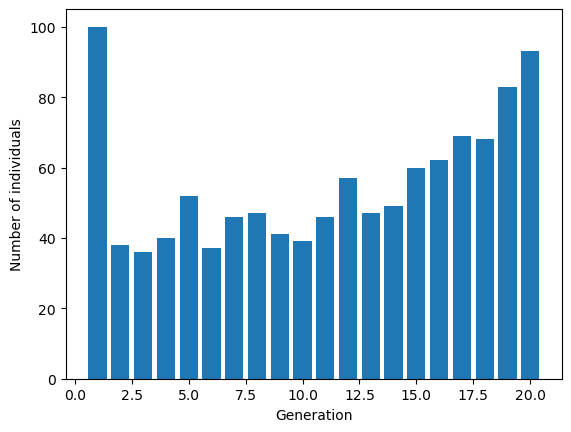

In [26]:
fig = plt.figure()
ax = fig.add_subplot()

ax.bar(np.arange(1, 1 + len(pop_size)), pop_size)
ax.set_xlabel("Generation")
ax.set_ylabel("Number of individuals")

plt.show(fig)

In [27]:
size_mean = np.array(list(map(np.mean, G_all)))
size_sd = np.array(list(map(np.std, G_all)))

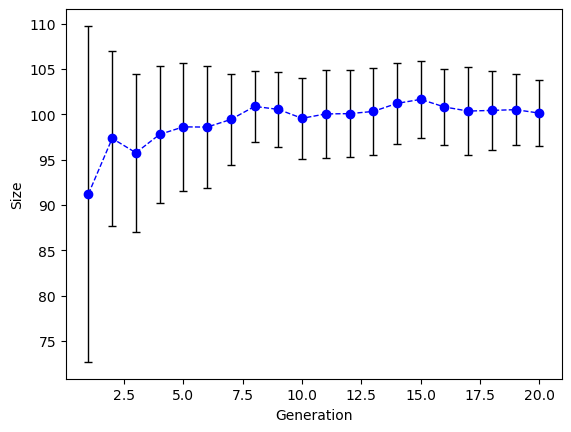

In [28]:
fig = plt.figure()
ax = fig.add_subplot()

ax.errorbar(
    np.arange(1, 1 + len(pop_size)), size_mean, yerr=size_sd,
    color="blue", marker="o", lw=1, ls="--", 
    ecolor="black", capsize=3.0
)

ax.set_xlabel("Generation")
ax.set_ylabel("Size")

plt.show(fig)

## Exercise: add extra complication(s) to the model above, then reimplement